# Prétraitement des données pour la prédiction des primes d'assurance

**Objectif**: Développer la stratégie de prétraitement qui maximise les estimations des primes d'assurances.

**Plan**:
- Gestion des types de données
- Split des données (en préservant l'intégrité des contrats)
- Comparaison des stratégies pour:
   - Gestion des valeurs manquantes
   - Gestion des outliers
   - Encodage des variables catégorielles
   - Gestion de l'asymétrie de la variable cible
- Sélection des meilleures stratégies
- Construction du pipeline final
- Évaluation sur le test set
- Sauvegarde

## 1. Import des librairies et chargement des données

In [49]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Pour le split
from sklearn.model_selection import GroupShuffleSplit, cross_val_score, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer

# Pour les imputations
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder

# Pour les encodages
from sklearn.base import BaseEstimator, TransformerMixin
import category_encoders as ce

# Pour SMOGN
import smogn

# Pour les modèles
from sklearn.linear_model import Ridge

# Configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
import sklearn
sklearn.set_config(transform_output="pandas")

# Chemins
notebooks_path = os.getcwd()
project_path = os.path.dirname(notebooks_path)
data_path = os.path.join(project_path, 'Data', 'DonneesPreparees', 'dataset_final.csv')
output_path = os.path.join(project_path, 'Outputs', 'Pretraitement')
os.makedirs(output_path, exist_ok=True)

In [50]:
# Chargement des données
df = pd.read_csv(data_path)
print("Dimensions:", df.shape)
df.head()

Dimensions: (78240, 17)


,age_vehicule_annees,categorie_mère,duree_garantie_jours,Contrat_id,garantie,marque,modèle,places,puissance,segment,type_vehicule,typeinter,typepermis,valeur_neuve,valeur_venale,y_cible,ville
0,17.026694,Tourisme (VP),182,1004-1010003466_GH_20230111_20230713,Recours / Défense,TOYOTA,AUTRE_TOYOTA,5.0,11.0,GENERALISTE,BERLINE,Bureau Direct,B,NaN,NaN,1017.0,BAMENDA
1,0.131417,2/3 Roues,363,6127-1500000493_GH_20230214_20240213,Recours / Défense,ROYAL,AUTRE_ROYAL,2.0,1.0,DEUX_ROUES,MOTO,Agent Général,A,NaN,NaN,308.0,MAROUA
2,0.131417,2/3 Roues,363,6127-1500000493_I2_20230214_20240213,Accident conducteur,ROYAL,AUTRE_ROYAL,2.0,1.0,DEUX_ROUES,MOTO,Agent Général,A,NaN,NaN,2500.0,MAROUA
3,23.129363,Tourisme (VP),363,6003-1010002803_GH_20230217_20240216,Recours / Défense,LEXUS,AUTRE_LEXUS,5.0,9.0,PREMIUM,SUV,Agent Général,B,NaN,NaN,2126.0,DOUALA
4,23.129363,Tourisme (VP),363,6003-1010002803_I_20230217_20240216,Transport de personnes,LEXUS,AUTRE_LEXUS,5.0,9.0,PREMIUM,SUV,Agent Général,B,NaN,NaN,10500.0,DOUALA


In [51]:
df.isna().sum()

age_vehicule_annees        12
categorie_mère              0
duree_garantie_jours        0
Contrat_id                  0
garantie                    0
marque                      0
modèle                      0
places                   1160
puissance                  48
segment                     0
type_vehicule               0
typeinter                   0
typepermis               6526
valeur_neuve            63731
valeur_venale           63700
y_cible                     0
ville                       0
dtype: int64

## 2. Gestion des types de données et sélection des colonnes

In [52]:
df.columns

Index(['age_vehicule_annees', 'categorie_mère', 'duree_garantie_jours',
       'Contrat_id', 'garantie', 'marque', 'modèle', 'places', 'puissance',
       'segment', 'type_vehicule', 'typeinter', 'typepermis', 'valeur_neuve',
       'valeur_venale', 'y_cible', 'ville'],
      dtype='object')

In [53]:
df['ville'].unique()

array(['BAMENDA', 'MAROUA', 'DOUALA', 'EBOLOWA', 'YAOUNDE', 'LIMBÉ',
       'NDOP', 'BAFOUSSAM', 'BUÉA', 'GAROUA', 'BALENG', 'NJOMBE-PENJA',
       'SANTA', 'BAFUT', 'NDJAMENA', 'KRIBI', 'AUTRE', 'NKAMBÉ', 'KUMBA',
       'KOUSSÉRI', 'DSCHANG', 'BERTOUA', 'NGAOUNDÉRÉ', 'KUMBO', 'BATIBO',
       'FUNDONG', 'FOUMBAN', 'TIKO', 'TUBAH', 'MBOUDA', 'FOUMBOT',
       'NKONGSAMBA', 'BAFANG', 'BALI'], dtype=object)

In [54]:
# Convertir les colonnes numériques en float si nécessaire
num_cols = ['age_vehicule_annees', 'duree_garantie_jours', 'places', 'puissance', 'valeur_neuve', 'valeur_venale', 'y_cible']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# On retire les colonnes avec trop de missing (valeur_neuve, valeur_venale) et on garde Contrat_id pour le split
cols_to_use = ['age_vehicule_annees', 'duree_garantie_jours', 'places', 'puissance',
               'categorie_mère', 'garantie', 'segment', 'type_vehicule', 'typeinter', 'typepermis',
               'y_cible', 'ville','marque','Contrat_id']
df_model = df[cols_to_use].copy()
print("Colonnes retenues:", df_model.columns.tolist())

Colonnes retenues: ['age_vehicule_annees', 'duree_garantie_jours', 'places', 'puissance', 'categorie_mère', 'garantie', 'segment', 'type_vehicule', 'typeinter', 'typepermis', 'y_cible', 'ville', 'marque', 'Contrat_id']


## 3. Split des données en préservant l'intégrité des contrats

In [55]:
X = df_model.drop(columns=['y_cible', 'Contrat_id'])
y = df_model['y_cible']
groups = df_model['Contrat_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

#X_train = X_train.drop(columns=['Contrat_id'])
#X_test = X_test.drop(columns=['Contrat_id'])

#print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

In [56]:
X_train.isna().sum()

age_vehicule_annees       10
duree_garantie_jours       0
places                   931
puissance                 43
categorie_mère             0
garantie                   0
segment                    0
type_vehicule              0
typeinter                  0
typepermis              5253
ville                      0
marque                     0
dtype: int64

## 4. Définition des colonnes et des utilitaires

In [57]:
num_cols_model = ['age_vehicule_annees', 'duree_garantie_jours', 'places', 'puissance']
cat_cols_model = ['categorie_mère', 'garantie', 'segment', 'type_vehicule', 'typeinter', 'typepermis', 'ville', 'marque']

# Fonction pour évaluer un préprocesseur avec un modèle Ridge simple en CV
def evaluate_preprocessor(preprocessor, X, y, cv=5):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=1.0, random_state=42))
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    return np.sqrt(-scores.mean())

# Fonction de clipping
def clip_outliers(X, cols, factor=1.5):
    X_clipped = X.copy()
    for col in cols:
        Q1 = X_clipped[col].quantile(0.25)
        Q3 = X_clipped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        X_clipped[col] = X_clipped[col].clip(lower_bound, upper_bound)
    return X_clipped

# Fonction pour supprimer les outliers (IQR)
def remove_outliers_iqr(X, y, cols, factor=1.5):
    X_clean = X.copy()
    y_clean = y.copy()
    for col in cols:
        Q1 = X_clean[col].quantile(0.25)
        Q3 = X_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        mask = (X_clean[col] >= lower_bound) & (X_clean[col] <= upper_bound)
        X_clean = X_clean[mask]
        y_clean = y_clean[mask]
    return X_clean, y_clean

# Encoders personnalisés (Frequency et Target)
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None):
        self.cols = cols
        self.freq_maps = {}
    
    def fit(self, X, y=None):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)
        if self.cols is None:
            if hasattr(X, 'columns'):
                self.cols = X.columns.tolist()
            else:
                self.cols = list(range(X.shape[1]))
                
        for col in self.cols:
            freq = X[col].value_counts(normalize=True)
            self.freq_maps[col] = freq
        return self
    
    def transform(self, X):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)
            
        X_encoded = X.copy()
        for col in self.cols:
            X_encoded[col] = X_encoded[col].map(self.freq_maps[col]).fillna(0)
        return X_encoded
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return self.cols
        return input_features

# Pour Target Encoding, on utilisera category_encoders.TargetEncoder directement

## 5. Comparaison des stratégies de gestion des valeurs manquantes

Comparaison des techniques d'imputation:
           technique    rmse_moyen
0        suppression  7.791783e+07
1  imputation_simple  7.416493e+07
2     imputation_knn  7.416524e+07


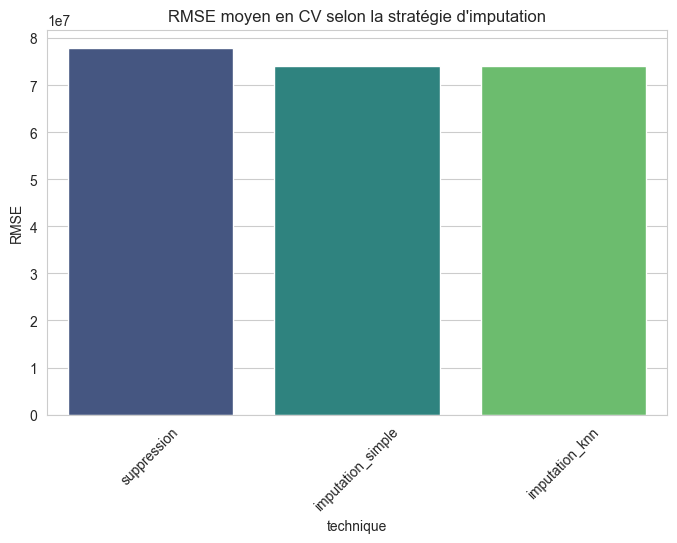


Meilleure technique d'imputation: imputation_simple


In [58]:
def comparer_techniques_imputation(X_train, y_train, cv=5):
    """
    Teste différentes stratégies d'imputation des valeurs manquantes.
    Retourne un DataFrame avec les RMSE moyens en CV.
    """
    results = []
    
    # 1. Suppression des lignes avec NaN
    X_train_drop = X_train.dropna()
    y_train_drop = y_train.loc[X_train_drop.index]
    preprocessor_drop = ColumnTransformer([
        ('num', 'passthrough', num_cols_model),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_model)
    ])
    pipeline_drop = Pipeline([
        ('preprocess', preprocessor_drop),
        ('regressor', Ridge(alpha=1.0, random_state=42))
    ])
    rmse_drop = np.sqrt(-cross_val_score(pipeline_drop, X_train_drop, y_train_drop, cv=cv, scoring='neg_mean_squared_error').mean())
    results.append({'technique': 'suppression', 'rmse_moyen': rmse_drop})
    
    # 2. Imputation simple (médiane pour num, mode pour cat)
    preprocessor_simple = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('passthrough', 'passthrough')
        ]), num_cols_model),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols_model)
    ])
    rmse_simple = evaluate_preprocessor(preprocessor_simple, X_train, y_train, cv)
    results.append({'technique': 'imputation_simple', 'rmse_moyen': rmse_simple})
    
    # 3. Imputation kNN pour numériques, mode pour catégorielles
    preprocessor_knn = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', KNNImputer(n_neighbors=5)),
            ('passthrough', 'passthrough')
        ]), num_cols_model),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols_model)
    ])
    rmse_knn = evaluate_preprocessor(preprocessor_knn, X_train, y_train, cv)
    results.append({'technique': 'imputation_knn', 'rmse_moyen': rmse_knn})
    
    df_results = pd.DataFrame(results)
    return df_results

# Exécution
df_imputation = comparer_techniques_imputation(X_train, y_train, cv=5)
print("Comparaison des techniques d'imputation:")
print(df_imputation)

# Visualisation
plt.figure(figsize=(8,5))
sns.barplot(data=df_imputation, x='technique', y='rmse_moyen', palette='viridis')
plt.title("RMSE moyen en CV selon la stratégie d'imputation")
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.show()

# Sélection de la meilleure
best_imputation = df_imputation.loc[df_imputation['rmse_moyen'].idxmin(), 'technique']
print(f"\nMeilleure technique d'imputation: {best_imputation}")

## 6. Comparaison des stratégies de gestion des outliers

Comparaison des techniques de gestion des outliers:
     technique    rmse_moyen
0        aucun  7.416524e+07
1     clipping  7.416524e+07
2  suppression  7.659367e+07


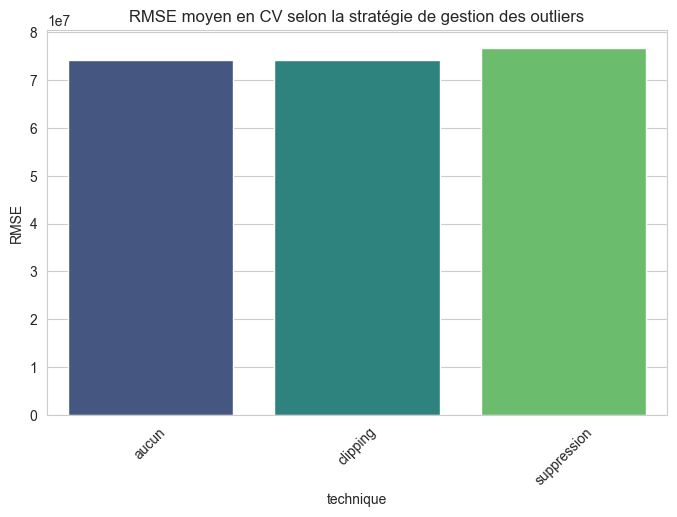


Meilleure technique de gestion des outliers: aucun


In [59]:
def make_preprocessor(imputation_strategy='knn', outlier_strategy='aucun', with_encoder=True):
    """Construit un préprocesseur avec imputation, clipping optionnel et encodage OneHot."""
    num_imputer = KNNImputer(n_neighbors=5)
    cat_imputer = SimpleImputer(strategy='most_frequent')
    
    num_steps = [('imputer', num_imputer)]
    
    num_pipeline = Pipeline(num_steps)
    
    cat_pipeline = Pipeline([
        ('imputer', cat_imputer),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    return ColumnTransformer([
        ('num', num_pipeline, num_cols_model),
        ('cat', cat_pipeline, cat_cols_model)
    ])

def evaluate_outlier_removal(X, y, cv=5):
    """CV manuelle pour la suppression des outliers car elle réduit le nombre d'échantillons."""
    num_imputer = KNNImputer(n_neighbors=5)
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    rmses = []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Imputation
        imputer = ColumnTransformer([
            ('num', num_imputer, num_cols_model),
            ('cat', SimpleImputer(strategy='most_frequent'), cat_cols_model)
        ])
        X_tr_imp = pd.DataFrame(imputer.fit_transform(X_tr), columns=num_cols_model+cat_cols_model)
        X_val_imp = pd.DataFrame(imputer.transform(X_val), columns=num_cols_model+cat_cols_model)
        
        # Suppression des outliers sur le train
        mask = pd.Series(True, index=X_tr_imp.index)
        for col in num_cols_model:
            Q1, Q3 = X_tr_imp[col].quantile(0.25), X_tr_imp[col].quantile(0.75)
            IQR = Q3 - Q1
            mask &= X_tr_imp[col].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
        if mask.sum() < 2:
        # Trop peu d'observations : on ne supprime rien
            X_tr_clean = X_tr_imp.copy()
            y_tr_clean = y_tr.copy()
        else:
            X_tr_clean = X_tr_imp.loc[mask]
            y_tr_clean = y_tr.loc[mask]
        
        # Encodage OneHot
        encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        X_tr_enc = encoder.fit_transform(X_tr_clean)
        X_val_enc = encoder.transform(X_val_imp)
        
        model = Ridge(alpha=1.0, random_state=42)
        model.fit(X_tr_enc, y_tr_clean)
        y_pred = model.predict(X_val_enc)
        rmses.append(np.sqrt(mean_squared_error(y_val, y_pred)))
    return np.mean(rmses)

def comparer_techniques_outliers(X_train, y_train, imputation_strategy='knn', cv=5):
    results = []
    
    # 1. Aucun traitement (juste imputation + encodage)
    preprocessor_none = make_preprocessor(imputation_strategy, outlier_strategy=None, with_encoder=True)
    rmse_none = evaluate_preprocessor(preprocessor_none, X_train, y_train, cv)
    results.append({'technique': 'aucun', 'rmse_moyen': rmse_none})
    
    # 2. Clipping
    preprocessor_clip = make_preprocessor(imputation_strategy, outlier_strategy='clipping', with_encoder=True)
    rmse_clip = evaluate_preprocessor(preprocessor_clip, X_train, y_train, cv)
    results.append({'technique': 'clipping', 'rmse_moyen': rmse_clip})
    
    # 3. Suppression
    rmse_remove = evaluate_outlier_removal(X_train, y_train, cv)
    results.append({'technique': 'suppression', 'rmse_moyen': rmse_remove})
    
    return pd.DataFrame(results)

df_outliers = comparer_techniques_outliers(X_train, y_train, imputation_strategy='knn', cv=5)
print("Comparaison des techniques de gestion des outliers:")
print(df_outliers)

# Visualisation
plt.figure(figsize=(8,5))
sns.barplot(data=df_outliers, x='technique', y='rmse_moyen', palette='viridis')
plt.title('RMSE moyen en CV selon la stratégie de gestion des outliers')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.show()

best_outlier = df_outliers.loc[df_outliers['rmse_moyen'].idxmin(), 'technique']
print(f"\nMeilleure technique de gestion des outliers: {best_outlier}")

## 7. Comparaison des stratégies d'encodage des variables catégorielles

Comparaison des techniques d'encodage:
   technique    rmse_moyen
0     onehot  7.416524e+07
1  frequency  7.680858e+07
2     target  7.384392e+07


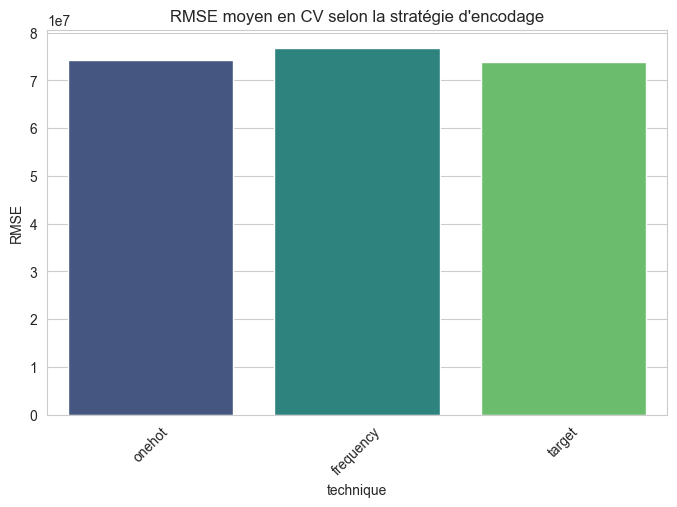


Meilleure technique d'encodage: target


In [60]:
def make_encoding_preprocessor(encoder, imputation_strategy='knn', outlier_strategy='aucun'):
    """Construit un préprocesseur avec imputation, clipping optionnel et l'encodeur choisi."""
    num_imputer = KNNImputer(n_neighbors=5)
    cat_imputer = SimpleImputer(strategy='most_frequent')
    
    num_steps = [('imputer', num_imputer)]
    num_pipeline = Pipeline(num_steps)
    
    # Pour l'encodeur, on le met directement dans le ColumnTransformer
    # Il doit traiter les colonnes catégorielles et retourner des numériques
    cat_pipeline = Pipeline([
        ('imputer', cat_imputer),
        ('encoder', encoder)
    ])
    
    return ColumnTransformer([
        ('num', num_pipeline, num_cols_model),
        ('cat', cat_pipeline, cat_cols_model)
    ])

def comparer_techniques_encodage(X_train, y_train, imputation_strategy='knn', outlier_strategy='aucun', cv=5):
    encoders = {
        'onehot': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        'frequency': FrequencyEncoder(),
        'target': ce.TargetEncoder(cols=cat_cols_model, smoothing=1, min_samples_leaf=10)
    }
    results = []
    for name, encoder in encoders.items():
        preprocessor = make_encoding_preprocessor(encoder, imputation_strategy, outlier_strategy)
        rmse = evaluate_preprocessor(preprocessor, X_train, y_train, cv)
        results.append({'technique': name, 'rmse_moyen': rmse})
    return pd.DataFrame(results)

df_encoding = comparer_techniques_encodage(X_train, y_train, imputation_strategy='simple', outlier_strategy='clipping', cv=5)
print("Comparaison des techniques d'encodage:")
print(df_encoding)

# Visualisation
plt.figure(figsize=(8,5))
sns.barplot(data=df_encoding, x='technique', y='rmse_moyen', palette='viridis')
plt.title("RMSE moyen en CV selon la stratégie d'encodage")
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.show()

best_encoding = df_encoding.loc[df_encoding['rmse_moyen'].idxmin(), 'technique']
print(f"\nMeilleure technique d'encodage: {best_encoding}")

## 8. Comparaison des stratégies de gestion de l'asymétrie de la cible

In [61]:
threshold = df["y_cible"].quantile(0.90)

rare = df[df["y_cible"] >= threshold]
rare.shape

(7936, 17)

Observations rares : 6299
Observations normales : 56464
SMOGN a échoué : redefine phi relevance function: all points are 1
Comparaison des techniques de gestion de l'asymétrie:
  technique    rmse_moyen
0  baseline  6.778598e+07
1       log  7.532524e+07
2      sqrt  7.340925e+07
3     smogn  1.000000e+10


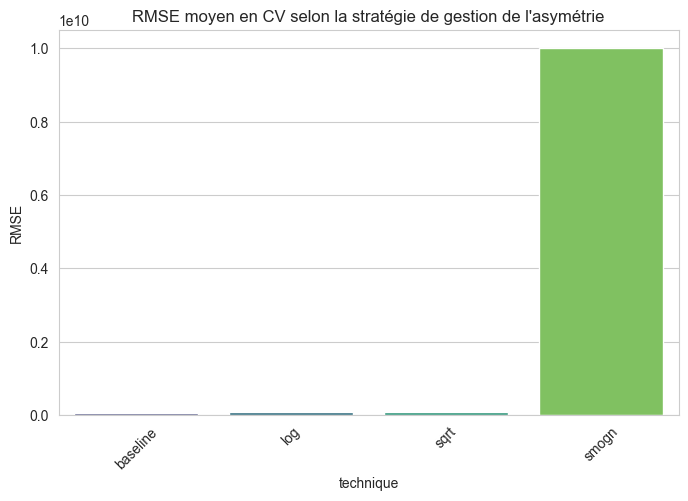


Meilleure technique de gestion de l'asymétrie: baseline


In [62]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.tree import DecisionTreeRegressor

def evaluate_target_transform(X, y, transformer, encoder, use_outlier, cv):
    preprocessor = make_encoding_preprocessor(encoder, 'knn', 'aucun' if use_outlier else 'none')
    
    base_pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('regressor', DecisionTreeRegressor(random_state=2, max_depth=8))
        #Ridge(alpha=1.0, random_state=42))
    ])
    
    # Transformation automatique de la cible (fit sur y transforme, predict réinverse automatiquement)
    if transformer == 'log':
        model = TransformedTargetRegressor(regressor=base_pipeline, func=np.log1p, inverse_func=np.expm1)
    elif transformer == 'sqrt':
        # S'assure que y >= 0 avant le sqrt
        model = TransformedTargetRegressor(regressor=base_pipeline, func=lambda v: np.sqrt(np.maximum(0, v)), inverse_func=np.square)
    else:
        model = base_pipeline

    # Evaluation directe du RMSE sur l'échelle d'origine de y
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_root_mean_squared_error')
    return -scores.mean()


def evaluate_smogn(X, y, encoder, use_outlier, cv, max_samples=2000):
    
    preprocessor = make_encoding_preprocessor(
        encoder,
        'simple',
        'clipping' if use_outlier else 'none'
    )

    try:
        # 1. Prétraitement
        X_encoded = preprocessor.fit_transform(X, y)

        if hasattr(X_encoded, "toarray"):
            X_encoded = X_encoded.toarray()

        data = pd.DataFrame(X_encoded)
        data.columns = [f"feature_{i}" for i in range(data.shape[1])]
        data["target"] = y.values
        data = data.reset_index(drop=True)

        # ======================================================
        # Sous-échantillonnage intelligent
        # ======================================================
        if len(data) > max_samples:

            # 10 % des valeurs les plus élevées
            threshold = data["target"].quantile(0.90)

            rare = data[data["target"] >= threshold]
            normal = data[data["target"] < threshold]

            print(f"Observations rares : {len(rare)}")
            print(f"Observations normales : {len(normal)}")

            remaining = max_samples - len(rare)

            if remaining > 0:

                normal = normal.sample(
                    n=min(remaining, len(normal)),
                    random_state=42
                )

                data = (
                    pd.concat([rare, normal])
                    .sample(frac=1, random_state=42)
                    .reset_index(drop=True)
                )

            else:
                # Cas où les observations rares dépassent max_samples
                data = rare.sample(
                    n=max_samples,
                    random_state=42
                ).reset_index(drop=True)

        # ======================================================
        # Application de SMOGN
        # ======================================================
        data_smogn = smogn.smoter(
            data=data,
            y="target",
            rel_thres=0.1,
            rel_method="auto",
            k=3,
            pert=0.02
        )

        X_smogn = data_smogn.drop(columns=["target"])
        y_smogn = data_smogn["target"]

        # ======================================================
        # Évaluation
        # ======================================================
        regressor = DecisionTreeRegressor(
            random_state=2,
            max_depth=8
        )

        scores = cross_val_score(
            regressor,
            X_smogn,
            y_smogn,
            cv=cv,
            scoring="neg_root_mean_squared_error"
        )

        return -scores.mean()

    except Exception as e:
        print(f"SMOGN a échoué : {e}")
        return 1e10
    
def comparer_techniques_gestion_asymetrie(X_train, y_train, encoder, use_outlier=True, cv=5):
    results = []
    
    # Baseline
    rmse_base = evaluate_target_transform(X_train, y_train, 'none', encoder, use_outlier, cv)
    results.append({'technique': 'baseline', 'rmse_moyen': rmse_base})
    
    # Log
    rmse_log = evaluate_target_transform(X_train, y_train, 'log', encoder, use_outlier, cv)
    results.append({'technique': 'log', 'rmse_moyen': rmse_log})
    
    # Sqrt
    rmse_sqrt = evaluate_target_transform(X_train, y_train, 'sqrt', encoder, use_outlier, cv)
    results.append({'technique': 'sqrt', 'rmse_moyen': rmse_sqrt})
    
    # SMOGN
    rmse_smogn = evaluate_smogn(X_train, y_train, encoder, use_outlier, cv)
    results.append({'technique': 'smogn', 'rmse_moyen': rmse_smogn})
    
    return pd.DataFrame(results)

# Choix de l'encodeur (on prend le meilleur de l'étape précédente)
if best_encoding == 'onehot':
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
elif best_encoding == 'frequency':
    encoder = FrequencyEncoder()
else:
    encoder = ce.TargetEncoder(cols=cat_cols_model, smoothing=1, min_samples_leaf=10)

df_asymmetry = comparer_techniques_gestion_asymetrie(X_train, y_train, encoder, use_outlier=(best_outlier=='clipping'), cv=5)
print("Comparaison des techniques de gestion de l'asymétrie:")
print(df_asymmetry)

# Visualisation
plt.figure(figsize=(8,5))
sns.barplot(data=df_asymmetry, x='technique', y='rmse_moyen', palette='viridis')
plt.title("RMSE moyen en CV selon la stratégie de gestion de l'asymétrie")
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.show()

best_asymmetry = df_asymmetry.loc[df_asymmetry['rmse_moyen'].idxmin(), 'technique']
print(f"\nMeilleure technique de gestion de l'asymétrie: {best_asymmetry}")

## 9. Sélection de variables avec RFE (Random Forest)

Après avoir déterminé les meilleures stratégies de prétraitement, nous nous intéressons maintenant à la sélection des variables. L'objectif est de réduire la dimensionnalité en ne conservant que les caractéristiques les plus pertinentes pour la prédiction, ce qui peut améliorer la généralisation et la performance du modèle.

Nous utilisons la méthode **RFE (Recursive Feature Elimination)** avec un **RandomForestRegressor** comme estimateur. RFE élimine itérativement les features les moins importantes jusqu'à atteindre le nombre souhaité. Nous allons déterminer ce nombre optimal par validation croisée.

### 9.1 Construction du préprocesseur final

Nous utilisons les meilleures stratégies identifiées précédemment :
- Imputation : KNN (pour les numériques) et mode (pour les catégorielles)
- Gestion des outliers : aucune (selon la conclusion)
- Encodage des variables catégorielles : Target Encoding
- Transformation de la cible : racine carrée (sqrt) pour réduire l'asymétrie

Nous créons un préprocesseur qui transforme les données brutes en une matrice numérique prête pour l'apprentissage.

In [63]:
# Import supplémentaire pour RFE
from sklearn.feature_selection import RFE, RFECV
from sklearn.ensemble import RandomForestRegressor

# Reprenons les meilleurs paramètres
best_imputation = 'imputation_knn'
best_outlier = 'aucun'       
best_encoding = 'target'     # target encoding
best_asymmetry = 'sqrt'

# Définir l'encodeur cible
encoder = ce.TargetEncoder(cols=cat_cols_model, smoothing=1, min_samples_leaf=10)

# Préprocesseur final
num_imputer = KNNImputer(n_neighbors=5) if best_imputation == 'imputation_knn' else SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

num_pipeline = Pipeline([
    ('imputer', num_imputer)
    # Pas de clipping car best_outlier = 'aucun'
])

cat_pipeline = Pipeline([
    ('imputer', cat_imputer),
    ('encoder', encoder)
])

preprocessor_final = ColumnTransformer([
    ('num', num_pipeline, num_cols_model),
    ('cat', cat_pipeline, cat_cols_model)
])

# Transformer les données d'entraînement en une matrice numérique
X_train_processed = preprocessor_final.fit_transform(X_train, y_train)
# Si l'encodeur cible a besoin de y, il l'utilise via fit_transform (déjà fait)
# On récupère les noms des colonnes si possible
if hasattr(preprocessor_final, 'get_feature_names_out'):
    feature_names = preprocessor_final.get_feature_names_out()
else:
    feature_names = [f"feat_{i}" for i in range(X_train_processed.shape[1])]

# Transformer la cible avec sqrt
y_train_sqrt = np.sqrt(np.maximum(0, y_train))

print(f"Dimensions des données transformées : {X_train_processed.shape}")

Dimensions des données transformées : (62763, 12)


### 9.2 Application de RFE(Recursive Feature Elimination) avec validation croisée
Nous utilisons RFECV pour sélectionner automatiquement le nombre optimal de features en minimisant l'erreur en validation croisée. Nous utilisons un RandomForestRegressor avec des paramètres raisonnables.

Nombre optimal de features sélectionnées : 10


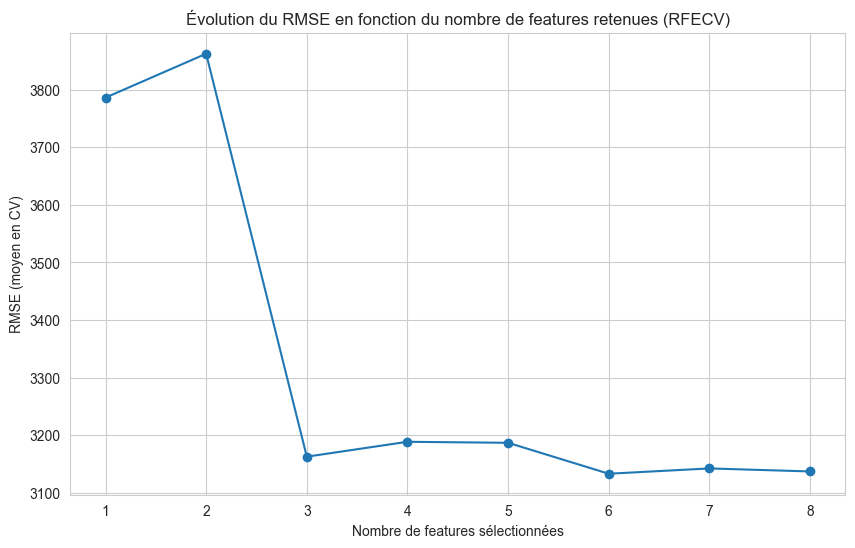

Features sélectionnées :
  - num__age_vehicule_annees
  - num__duree_garantie_jours
  - num__places
  - num__puissance
  - cat__categorie_mère
  - cat__garantie
  - cat__segment
  - cat__typeinter
  - cat__ville
  - cat__marque


In [64]:
# Définir l'estimateur RandomForest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# RFECV avec scoring RMSE
rfecv = RFECV(
    estimator=rf,
    step=1,                # retirer une feature à chaque itération
    cv=4,
    scoring='neg_root_mean_squared_error',
    min_features_to_select=5,  # nombre minimum de features à garder
    n_jobs=-1
)

# Adapter sur les données transformées
rfecv.fit(X_train_processed, y_train_sqrt)

# Nombre optimal de features
optimal_n_features = rfecv.n_features_
print(f"Nombre optimal de features sélectionnées : {optimal_n_features}")

# Visualisation du score en fonction du nombre de features
plt.figure(figsize=(10,6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
         -rfecv.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Nombre de features sélectionnées')
plt.ylabel('RMSE (moyen en CV)')
plt.title('Évolution du RMSE en fonction du nombre de features retenues (RFECV)')
plt.grid(True)
plt.show()

# Indices des features sélectionnées
selected_indices = rfecv.support_
selected_features = [feature_names[i] for i, selected in enumerate(selected_indices) if selected]
print("Features sélectionnées :")
for feat in selected_features:
    print(f"  - {feat}")

### 9.3 Évaluation du modèle avec et sans sélection
Nous comparons les performances d'un modèle Ridge (ou RandomForest) entraîné sur l'ensemble des features par rapport à celui entraîné sur les features sélectionnées.

In [65]:
# Définir le pipeline complet (prétraitement + régression)
from sklearn.compose import TransformedTargetRegressor

def build_pipeline(use_selection=False):
    # Préprocesseur (on le réutilise)
    preprocessor = preprocessor_final
    
    # Régresseur Ridge (ou RandomForest) - on peut utiliser Ridge pour la cohérence
    regressor = RandomForestRegressor()
    
    if use_selection:
        # On ajoute une étape de sélection manuelle (seulement les colonnes sélectionnées)
        # On ne peut pas le faire directement dans un pipeline car RFECV a déjà déterminé les colonnes.
        # On va plutôt créer un sélecteur personnalisé ou utiliser une étape de transformation.
        # Ici, on va construire un pipeline avec un sélecteur qui garde les colonnes sélectionnées.
        from sklearn.base import TransformerMixin, BaseEstimator
        class ColumnSelector(BaseEstimator, TransformerMixin):
            def __init__(self, indices):
                self.indices = indices
            def fit(self, X, y=None):
                return self
            def transform(self, X):
                if isinstance(X, pd.DataFrame):
                    return X.iloc[:, self.indices]
                else:
                    return X[:, self.indices]
        
        selector = ColumnSelector(selected_indices)
        # On combine préprocesseur + sélecteur (mais le préprocesseur transforme déjà)
        # On va plutôt créer un pipeline avec le préprocesseur, puis le sélecteur, puis le régresseur.
        full_pipeline = Pipeline([
            ('preprocess', preprocessor),
            ('select', selector),
            ('regressor', regressor)
        ])
    else:
        full_pipeline = Pipeline([
            ('preprocess', preprocessor),
            ('regressor', regressor)
        ])
    
    # Enveloppe pour la transformation de la cible (sqrt)
    if best_asymmetry == 'sqrt':
        model = TransformedTargetRegressor(
            regressor=full_pipeline,
            func=np.sqrt,
            inverse_func=np.square,
            check_inverse=False
        )
    else:
        model = full_pipeline
    
    return model

# Modèle sans sélection
model_full = build_pipeline(use_selection=False)
# Modèle avec sélection
model_sel = build_pipeline(use_selection=True)

# Évaluation en CV sur les données d'entraînement
cv = 4
score_full = cross_val_score(model_full, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')
score_sel = cross_val_score(model_sel, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')

print(f"RMSE moyen (sans sélection) : {-score_full.mean():.4f} ± {score_full.std():.4f}")
print(f"RMSE moyen (avec sélection) : {-score_sel.mean():.4f} ± {score_sel.std():.4f}")

RMSE moyen (sans sélection) : 66725243.7497 ± 25787036.2092
RMSE moyen (avec sélection) : 66622622.1589 ± 26085608.5141


In [66]:
# Noms des features sélectionnées
selected_features_df = pd.DataFrame({'feature': selected_features})
selected_features_df

,feature
0,num__age_vehicule_annees
1,num__duree_garantie_jours
2,num__places
3,num__puissance
4,cat__categorie_mère
5,cat__garantie
6,cat__segment
7,cat__typeinter
8,cat__ville
9,cat__marque


## 9. Conclusion

Nous avons développé une stratégie de prétraitement basée sur des comparaisons systématiques des techniques pour chaque étape. Les meilleures stratégies ont été sélectionnées et intégrées dans un pipeline final, évalué sur un ensemble de test indépendant. Le pipeline est prêt à être utilisé pour de nouvelles prédictions.

Les meilleures stratégies retenues sont:
- Imputation: KNN Imputation
- Outliers: Aucun traitement car la suppression retire les individus
- Encodage: target encoding (au lieu de one hot pour éviter le piège des dimensions)
- Asymétrie: sqrt transformation